<a href="https://colab.research.google.com/github/r-okotie179/diseaseModelling/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model I
Inspired by the distribution of farmlands and their connection networks. The disease I will work towards is BSE (less variables) and see how the sharing of food-stock (and how the use of animal meal can transfer between farms), as well as the delayed emergence of symptoms and what response would be best suited for this.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Used `Claude Sonnet 5 Extra Thinking` to know roughly what the median value of cattle there were in the UK; I assumed it would follow an exponential distribution (where a small amount of farms would have large cattle sizes, but probably less centralised food sources; it would contain very high amounts of shared transportation and shared food sources).

Improvements: Distribution with the below equation now presents more apparently the larger, more infrequent farming clusters:

```
f = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)
```

Further improvements: I wanted to make the appearance of a high number of cattle on a given farm more unlikely. Further, the "noise" effect of the sine wave just means that not every small farm has precisely the same number of cattle.

$$f(x) \propto \frac{e^{ax^\frac{1}{x}} - 1}{e^a - 1}$$

In [2]:
# distribution of number of cattle
## it can and will be improved with other distributions
## I will sample uniformly from f

x = np.linspace(0, 100, 1000)
a = 40 # median
s_factor = 25 # scaling factor
#f_range = np.floor((50) * np.exp(((x-95)/np.sqrt(x))*5) + (a)) + np.abs(a-10) * np.sin(x**x)
f_range = np.ceil((1/a) * (np.exp(s_factor*(x**(1/x))) -1)/(np.exp(s_factor) - 1) + np.abs(a-a/2) * np.sin(x*x + s_factor + np.sin(s_factor * (x**x))) + a)

/tmp/ipykernel_1163/2792391357.py:9: RuntimeWarning: divide by zero encountered in divide
  f_range = np.ceil((1/a) * (np.exp(s_factor*(x**(1/x))) -1)/(np.exp(s_factor) - 1) + np.abs(a-a/2) * np.sin(x*x + s_factor + np.sin(s_factor * (x**x))) + a)


/tmp/ipykernel_3652/2110165625.py:9: RuntimeWarning: divide by zero encountered in divide
  f_range = np.ceil((1/a) * (np.exp(s_factor*(x**(1/x))) -1)/(np.exp(s_factor) - 1) + np.abs(a-a/2) * np.sin(x*x + s_factor + np.sin(s_factor * (x**x))) + a)


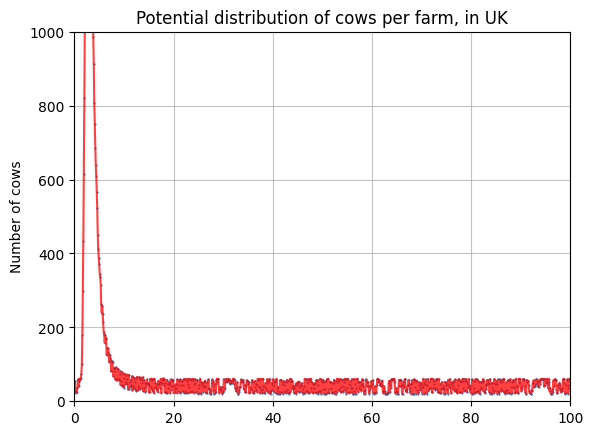

In [ ]:
plt.xlim(0, 100)
plt.ylim(0, 1000)
plt.scatter(x, f_range, s=.3)
plt.plot(x, f_range, color='r', alpha=.75)
plt.title("Potential distribution of cows per farm, in UK")
plt.ylabel("Number of cows")
plt.grid(alpha=0.75)
plt.show()

#print(f_range)

In [3]:
scale = 10 # size of gridding

def farmland(n): # output n nodes
  farmlands = []
  for each_farm in range(n):
    # num cattle, position, centrality (1 indicates entire food source is shared and eaten from one big piece, 0 implies each individual sheep has its own feeding  )
    nc = np.random.choice(f_range).astype(int)
    position = (np.random.uniform(-scale,scale), np.random.uniform(-scale,scale))
    farmlands.append([nc,position])
  df_farms = pd.DataFrame(farmlands, columns=['Cattle No.', 'Position'])
  return df_farms # as dataframe

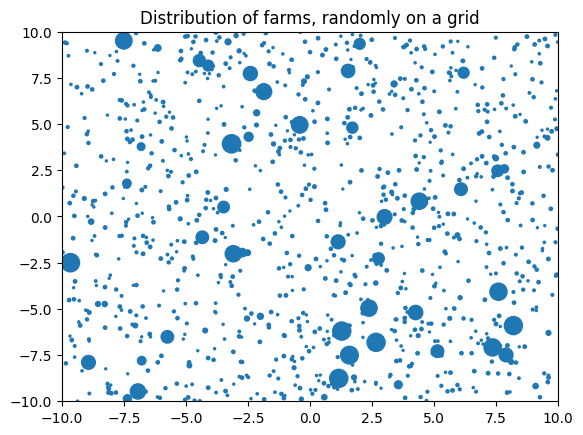

In [ ]:
test = farmland(1000)
pos = np.array(test['Position'].tolist())

plt.scatter(pos[:,0], pos[:,1], s=np.array(test['Cattle No.'])/scale, alpha=1)
plt.xlim(-scale,scale)
plt.ylim(-scale,scale)
plt.title("Distribution of farms, randomly on a grid")
plt.show()

## Connections of each graph
A directed graph is one in which the magnitude of the edge weight going from nodes A -> B is not necessarily the same as B -> A.

I want to represent the farms like this since large farms would be (**in my head, based off of nothing**) more likely to be the focal point of distribution networks.

I want the connections between farms to be a function of their proximity and size and iterate this over all farms (a wholly inefficient algorithm). This inefficacy prompted me to consider ways of doing such searches more efficiently, which will be seen later.

The first step of this is to have a function for the probability of an edge occuring in one direction between two nodes:

$$\text{Let u} =\frac{x_{n} \text{dist}(x_{p}, y_{p})}{y_{n}}$$

$$P(x_i, x_j) = f(u)$$
Where $x_n$ is the number of cattle on a given farm, $x_p$ is its position and the function $\text{dist}(x,y)$ computes the distance between two coordinate values.

The $\frac{x_n}{y_n}$ term encodes that *size matters* and then larger farms would be more likely to send resources to smaller farms (likely in some assimilation attempt to grow). This was inspired by the idea of equilibrium. If $x_n << y_n$ it reduces the overall chance of an edge occuring in that direction.

The distance between the nodes is trivial.

For $f(x)$, I would like a function that can compress positive, real inputs to outputs between 0 and 1, since probabilities can only be in that range.

I will print out some potential functions that has this quality (of compressinf real inputs to a nice range) and try to understand why some are used over others.

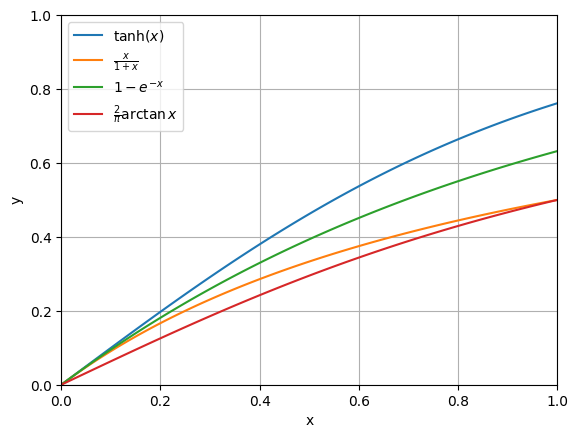

In [ ]:
'''
f(x) contenders:
tanhx, 2(arctanx)/pi, 1-e^-x, x/(1+x)
I used Claude to get this list, although it's quite standard
'''
z = np.linspace(0, 1, 100)
tanh = (np.exp(2 * z) - 1)/(np.exp(2 * z) + 1)
polyn = z/(1+z)
arctan = (2/np.pi) * np.arctan(z)
exp = 1 - np.exp(-z)

plt.plot(z, tanh, label=r'$\tanh(x)$')
plt.plot(z, polyn, label=r'$\frac{x}{1+x}$')
plt.plot(z, exp, label=r'$1-e^{-x}$')
plt.plot(z, arctan, label=r'$\frac{2}{\pi}\arctan{x}$')


plt.ylim(0,1)
plt.xlim(0,1)
#plt.axis('equal')

plt.xlabel('x')
plt.ylabel('y')

plt.grid()
plt.legend()
plt.show()

Since this range is much smaller than what my input would be (is my assumption, I will do tests before this), I was thinking of taking the natural logarithm of my raw inputs and the seeing what the output would be and calling it a day.

### Creating edges
This section will include many, many tangents all in the name of constructing the edges for this code.

Below is the rough pseudocode that all of this leads towards, where there is a construction of edges each with a randomly derived edge weight.

In [ ]:

'''
for node in df_farms:
  neighbours = get_knn(node, k) # k ~ 10-15
  for idx in range(k):
    comp_node = neighbours[idx]
    p = f(node, comp_node)
    rand = np.random.uniform(0,1)
    if rand <= p:
      edge_update(node, comp_node, rand)
'''

This function very simply computes the u value. It will probably be an internal function within a class (or called within the `p(x,y)` function).

In [ ]:
# calculate u
def u(a,b): # a and b are coordinates
  a_num = a['Cattle No.']
  b_num = b['Cattle No.']
  a_pos = a['Position']
  b_pos = b['Position']

  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  return u.astype('float')

Now the tangent is such that, when I want to find nodes that are in a given range from the point, I would have to search the entire space of nodes and then compute their distances and add to the list those which I think are appropriate.

Which is silly.

So I was thinking of:
- ordering the database in terms of location (how)
- understanding different sorting algorithms, how they work and their optimisation
- getting this finished in the next session where I have connected edges to each point (and maybe an assigning of edges, stored into the node values as a dictionary since its directed).

#### KD-Tree
A k-dimensional tree is a data structure that partitions a list of data into k-dimensions such that it is faster to search through. For my algorithm searching for the *m* nearest node will reduce from $O(n^2)$ to $O(n\log{n})$ time complexity and will help me when I grow the no. farms.

Also, meant I thought about optimising things.

I will be following the work of @brewingacupofdata

In [4]:
pip install binarytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.4/115.4 kB 5.3 MB/s eta 0:00:00


In [5]:
from binarytree import tree, Node # idk what this does
from math import floor # ik what this does

In [6]:
'''
@brewingacupofdata might be the goat; I have followed through his tutorial rather than using Claude's
'''

class MyNode(Node):
  def __init__(self, _id, data, axis, idx):
    super().__init__(_id)
    self.data = data
    self.axis = axis
    self.idx = idx

class KD_Tree:
  def __init__(self, data):
    self.data = data
    self.tree = None

  def _build(self, points, depth): # this is an internal function meaning it can only be called in this class
    k = len(points.columns) # assuming data is in pandas.DataFrame
    _axis = depth % k
    _column = points.columns[_axis]


    if len(points) == 0:
      return None
    objects_list = points.sort_values(by=[_column], ascending=True) # sorting data based on pandas notation
    if len(objects_list)%2 == 0:
      median_idx = int(len(objects_list)/2)
    else: # if odd
      median_idx = floor(len(objects_list)/2)

    # numpy stores data like numpy.float64 which isn't unpacked in different libraries
    node = MyNode(_id = round(objects_list.iloc[median_idx][_column].item(), 3),
                  data = objects_list.iloc[median_idx],
                  axis = _column,
                  idx = median_idx)
    node.left = self._build(objects_list.iloc[0:median_idx], depth+1)
    node.right = self._build(objects_list.iloc[median_idx+1:], depth+1)
    return node

  def build(self):
    self.tree = self._build(self.data, depth=0)

  #####

  def _nearest(self, query, node, best_node, best_distance):
    # node = current_node
    if not node:
      return best_node, best_distance

    d = np.linalg.norm(query.values[0] - node.data.values).item() # assuming query is pd.DataFrame row

    if d < best_distance:
      best_node = node
      best_distance = d

    # now deciding which side of tree to progress down

    if query[node.axis].values[0] < node.data[node.axis]:
      good_side = node.left
      bad_side = node.right
    else:
      good_side = node.right
      bad_side = node.left

    best_node, best_distance = self._nearest(query, good_side, best_node, best_distance)

    if abs(node.data[node.axis] - query[node.axis].values[0]) < best_distance:
      best_node, best_distance = self._nearest(query, bad_side, best_node, best_distance)

    return best_node, best_distance # a successful recursive algorithm

  #####

  def _k_nearest(self, query, node, k_list, k):
    if not node:
        return k_list

    d = np.linalg.norm(query.values[0] - node.data.values).item()

    if len(k_list) < k:
        k_list.append([node, d])
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        if d < k_list[worst_idx][1]:
            k_list[worst_idx] = [node, d]

    if query[node.axis].values[0] < node.data[node.axis]:
        good_side, bad_side = node.left, node.right
    else:
        good_side, bad_side = node.right, node.left

    k_list = self._k_nearest(query, good_side, k_list, k)

    # prune condition: only descend bad_side if it could still contain
    # a point closer than your current worst (or you don't have k yet)
    if len(k_list) < k:
        should_check_bad_side = True
    else:
        worst_idx = max(range(len(k_list)), key=lambda i: k_list[i][1])
        should_check_bad_side = abs(node.data[node.axis] - query[node.axis].values[0]) < k_list[worst_idx][1]

    if should_check_bad_side:
        k_list = self._k_nearest(query, bad_side, k_list, k)

    return k_list

  ######

  def get_nn(self, query): # actually calling the nearest neighbour
    return self._nearest(query, self.tree, best_node = None, best_distance = np.inf)

  def get_knn(self, query, k):
    return self._k_nearest(query, self.tree, k_list=[], k=k)

The KNN function was mostly written by me, but I gave the polishing it up to `Claude` since I need to focus more on the model, rather than searching for neighbours. This detour took like 2 days because I'm an idiot.

In [ ]:
positions_df = pd.DataFrame(test['Position'].tolist(), columns=['x', 'y'])
kd = KD_Tree(positions_df)
kd.build() # build tree of nodes

In [ ]:
query = pd.DataFrame([test['Position'][9]], columns= positions_df.columns)
res = kd.get_nn(query)
res2 = kd.get_knn(query, 15)
print(res) # result
print(res[0].data.values) # the actual coordinate

pos_data = [[item[0], item[1]] for item in res2]
print(pos_data)

(Node(-5.906), 0.0)
[-5.90564566  5.96042008]
[[Node(5.591), 0.5031065919592932], [Node(-6.687), 0.797814161326544], [Node(-6.424), 0.8058597989976681], [Node(5.735), 0.8984248728958854], [Node(6.045), 1.192097294660513], [Node(6.467), 0.723319554353125], [Node(-6.206), 0.4589279480365481], [Node(5.643), 0.39626380205643214], [Node(-5.906), 0.0], [Node(6.72), 0.9643419360176425], [Node(6.19), 0.23063912369103406], [Node(-5.8), 0.5727527775967387], [Node(5.12), 0.8566104669227836], [Node(5.358), 0.7138250535412504], [Node(6.193), 0.84676874135323]]


Now this has done, I can return to the creation of edges (now that I know who my neighbours are) and then continue from there.

### Actual implementaton of edges

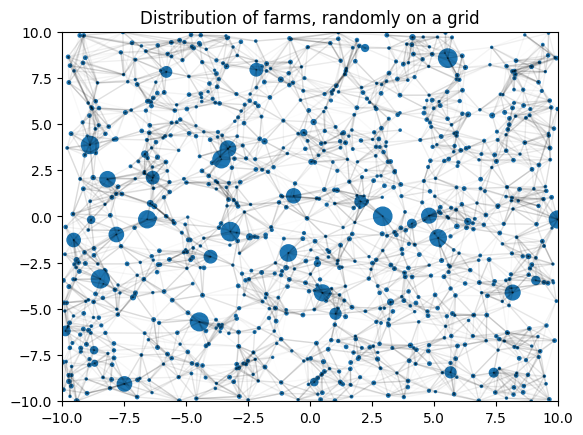

In [ ]:
'''
for node in df_farms:
  neighbours = get_knn(node, k) # k ~ 10-15
  for idx in range(k):
    comp_node = neighbours[idx]
    p = f(node, comp_node)
    rand = np.random.uniform(0,1)
    if rand <= p:
      edge_update(node, comp_node, rand)
'''

# calculate u
def u(a,b): # a and b are coordinates
  a_num = a['Cattle No.']
  b_num = b['Cattle No.']
  a_pos = np.array(a['Position'])
  b_pos = np.array(b['Position'])

  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  return u.astype('float')

def f(a,b):
  # this function just scales the output of u(x,y) so that it is between 0 and 1
  z = u(a,b)
  q = (2/np.pi) * np.arctan(z)
  return q

k=15

for node_idx in range(len(test)):
    node = test.iloc[node_idx]
    query = pd.DataFrame([node['Position']], columns=positions_df.columns)
    neighbours = kd.get_knn(query, k)

    for idx in range(k):
        comp_node_obj, comp_dist = neighbours[idx]
        comp_node = test.loc[comp_node_obj.data.name]

        p = f(node, comp_node)
        rand = np.random.uniform(0, 1)
        if rand <= p:            x = (node['Position'][0], comp_node['Position'][0])
            y = (node['Position'][1], comp_node['Position'][1])
            plt.plot(x, y, linewidth=1, c='black', alpha = rand/5)

plt.scatter(pos[:,0], pos[:,1], s=np.array(test['Cattle No.'])/scale, alpha=1)
plt.xlim(-scale,scale)
plt.ylim(-scale,scale)
plt.title("Distribution of farms, randomly on a grid")
plt.show()

https://kingaa.github.io/clim-dis/

This link shows more detail on next steps beyond the FMD model.

### Rejection of BSE Model

It would be a diversion from my construction: since food meal is centralised through a few suppliers that every farm woul likely take from, it would form a bipartite graph. This structure is something I am already exploring in a different project (`charity_idea.ipynb`) and so a more conventional network transmission model would be more interesting to explore.

Thus, I will no longer explore BSE.

### FMD Model
I will model the chance of an infection occuring to be in one of two ways:
- direct contact (e.g. lorry transporting equipment between farms that contains virus on it)
- wind (i.e. virus is spread through air; much lower probability of infection but has a high impact).

For the wind assuming, the probability of infection will follow an inverse square distribution ($\frac{1}{d^2}$) and be scaled by a small factor. Seeing how this factor changes the disease spread will be interesting.

#### Within Farms
Within each farm, the logic be similar to the Eyam model.

The farm size is already defined at $N$.

$$N = S + I + D$$

This model is such that no cattle survives and thus the only states present are susceptible, infected and dead.

----

**Future Model**: I hope to get a model that can include both recovered and culled cattle, so that the response to policy could be quantified.

----

Similar to Andrew French's model, that I explored in more detail in `chapter_2_5.ipynb`, I will state these as the expected change in values of $S, I, \& D$.

$$\Delta S = - \beta S I \Delta t$$
$$\Delta D = \alpha I \Delta t$$
$$\Delta I = (\beta S - \alpha)I\Delta t$$

These will then be sampled with a Poisson distribution across each timestep.

In [ ]:
'''
# adding new columns in the pandas dataframe

# setting susceptible equal to cattle no.

# defining here values of beta and alpha (as 1)

# running the simulation such that it updates the quality of the infective and dead population

# understand how to reset cattle numbers for the running of the stochastic sim (whilst remaining edge connections)
I think the quality in the columns could just be a list, that is called as an array to plot.

# plotting this for one farm and the aggregrate of farms on the plot
At each time step, there is a global probablility of a farm being infected.
This would be similar to the BSE model, except for no dynamics between suppliers (where suppliers could also act like farms) and farms in a bipartite graph.
'''

In [ ]:
num_rows = test.shape[0]
#zeroes_list = np.zeros(num_rows) # this is an error; need to actually have the structure be [[0],[0]...,[0]] rather than an array of 0s

new_columns = pd.DataFrame({"Susceptibles":[[int(s)] for s in test['Cattle No.']], "Infectives":[[0] for __ in range(num_rows)], "Dead":[[0] for _ in range(num_rows)]})
test = pd.concat([test, new_columns], axis=1)

In [ ]:
alpha =1
beta =1

/tmp/ipykernel_3913/2725873368.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


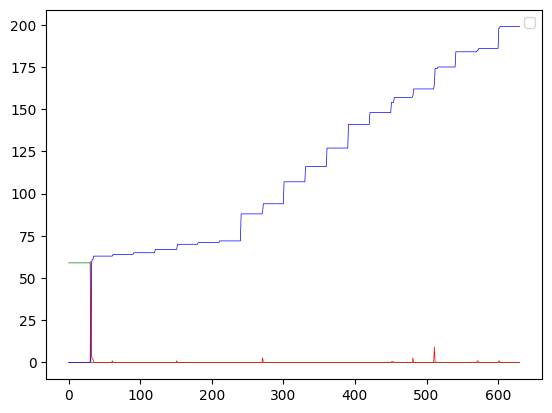

In [ ]:
## further notes on this was from the `chapter_2_5.ipynb` file
def delta_s(s, i, t):
  e = beta * s * i * t # expected value
  return np.random.poisson(lam=e)

def delta_d(i, t):
  e = alpha * i * t
  return np.random.poisson(lam=e)

def intra_farm(ID, t, step): # make the dataframe be the input (for non-testing versions of this)
  si = test.at[ID, 'Susceptibles'][-1]
  ii = test.at[ID, 'Infectives'][-1]
  di = test.at[ID, 'Dead'][-1]

  if step ==0:
    ii = np.random.uniform(0.1, 15)

  x = delta_s(si, ii, t) # since beta and delta t are constants
  y = delta_d(ii, t)

  i2 = max(0, (ii + x - y))
  s2 = max(0, (si - x))
  d2 = di + y

  test.at[ID, 'Susceptibles'] = test.at[ID, 'Susceptibles'] + [s2]
  test.at[ID, 'Infectives'] = test.at[ID, 'Infectives'] + [i2]
  test.at[ID, 'Dead'] = test.at[ID, 'Dead'] + [d2]

ID = 17
time_range = 30 # days
dt = 1 #day

'''
How to replicate the stochastic model?
How to persist the dataframe quality?
I will create a copy of the database in the loop (for stochastic running; maybe delegate that to a diff function)
This way it make the data better for a test env
'''

for step in range(time_range):
  intra_farm(ID, dt, step)

s = test.at[ID, 'Susceptibles']
i = test.at[ID, 'Infectives']
d = test.at[ID, 'Dead']

plt.plot(range(len(s)), s, color='g', lw=0.5)
plt.plot(range(len(i)), i, color='r', lw=0.5)
plt.plot(range(len(d)), d, color='b', lw=0.5)
plt.legend()
plt.show()

#### Between Farms
For this model (again, based on nothing since I will critique all assumptions in second pass of this), I will be basing probability assumptions on:

- strength of edges between neighbours
- the ratio of infectives on neighbouring farm
- spatial proximity to farm*

*This will require a lot of searches at each time step (I was thinking of an inverse-square relationship) and thus will be added when I know how to optimise code.

My current solution for this, will be updating the local $\Delta S$ to be dependent on external factors:

$$\Delta S_i = -(\beta S_i I_i + \gamma \sum_{n=0}^{N} w_n I_n) \Delta t$$

The additional term $\sum_{n=0}^{N} w_n I_n$ represents the sum of the edge weights of the neighbours.

When coding this, $w_n$ will actually mean $w_{ji}$ and represent the direction of the edge going into the focal node (rather than going outward).

A change I will make to the equation is normalising the neighbouring infective numbers. The reason is more vibe-based than anything but an explanation I have:*knowing that your nearest farm has 50 infected cattle could either mean that a very small amount of cattle are infected or the entire stock is*. This logic can then determine a heuristic idea of what proportion of used equipment would be infected and potentially transmitted to a neighbouring farm.  

This intuition can inform improvements to this model, where the rates of change within neighbouring farms could be used to influence the policy addition of this model.

Thus, this is the improved equation:
$$\Delta S_i = -(\beta S_i I_i + \gamma \sum_{n=0}^{N} w_n \frac{I_n}{N_n}) \Delta t$$

Another assumption of this is that I assume the edge weight quantities are linearly proportional to an individual cattle's probability of infection. However, since I have no information to base this off of, it is a reasonable starting point to be redefined later.

For this code to work, however, I will need to do the mass migration into `networkx`, which will be done now.

In [7]:
import networkx as nx

In [8]:
sample = farmland(85)

G = nx.DiGraph()

# node creation
# node attributes are lists so that a time series plot can be constructed
for idx, farm in sample.iterrows():
  G.add_node(idx,
    position=farm['Position'],
    N=farm['Cattle No.'],
    S=[farm['Cattle No.']],
    I=[0],
    D=[0],
    dS = 0,
    dI = 0,
    dD = 0
  )

#v = G.nodes[5]['N']
#print(np.array(v))

There is an issue with the distribution of edge weights such that there is a cluster near 1.

This will require me to know (beforehand) the std and mean of the distribution to have a more 'reasonable' distribution.

However, this skew will just be something to live with on the first pass of this code.

In [9]:
def u(a,b): # node characteristics
  a_num = G.nodes[a]['N']
  b_num = G.nodes[b]['N']
  a_pos = np.array(G.nodes[a]['position'])
  b_pos = np.array(G.nodes[b]['position'])
  u = (a_num * np.linalg.norm(a_pos - b_pos)) / b_num
  u = (np.log(u+0.001)) # to avoid log or 0 error
  return u.astype('float')

def f(a,b):
  z = u(a,b)
  q = (2/np.pi) * np.arctan(z)
  return np.abs(q)

In [10]:
# edge creation
k=9 # slider pararmeter

pos = nx.get_node_attributes(G, 'position')
pos_attr = pd.DataFrame(list(pos.values()), columns=['x','y'])
kdt = KD_Tree(pos_attr)
kdt.build()

for node_idx in range(len(sample)):
  node = G.nodes[node_idx]

  # query must be a DataFrame
  qry = pos_attr.iloc[[node_idx]]
  neighbours = kdt.get_knn(qry, k)

  for idx in range(k):
    comp_node_obj, comp_dist = neighbours[idx]
    comp_node = sample.loc[comp_node_obj.data.name]
    #print(f"{comp_node.name}\n")
    n = node_idx
    c = comp_node.name
    p = f(n, c)
    rand = np.random.uniform(0, 1)
    dnar = np.random.uniform(0,1) # there is now random chance of connection, since I don't want to spend more time on this
    #plt.scatter(node_idx, p)
    if rand <= dnar:
      G.add_edge(n, c, weight=p)

#plt.ylim(0,1)
#plt.grid(alpha=0.77)
#plt.show()

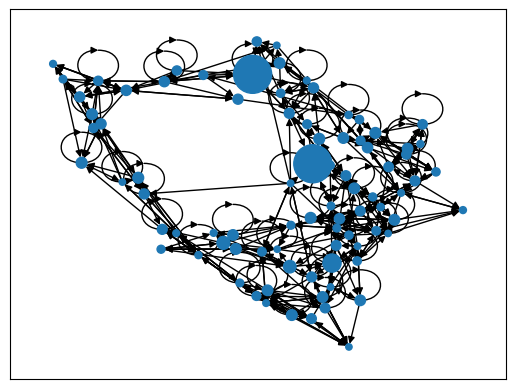

In [13]:
#pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
pos = nx.spring_layout(G, seed=7)
node_sizes = [G.nodes[node]['N'] for node in G.nodes]

nx.draw_networkx(G, pos=pos, node_size=node_sizes, arrows=True, with_labels=False)

In [14]:
n_len = len(G.nodes())
e_len = len(G.edges())

print(n_len, e_len)

85 398


#### updated intra-farm dynamics in networkx

In [33]:
alpha=.001
beta=.001

In [34]:
def delta_s(s, i, t):
  e = beta * s * i * t
  return np.random.poisson(lam=e)

def delta_d(i, t):
  e = alpha * i * t
  return np.random.poisson(lam=e)

def intra_farm(node, t, step):
  si = G.nodes[node]['S'][-1]
  ii = G.nodes[node]['I'][-1]
  di = G.nodes[node]['D'][-1]

  if step ==0:
    ii = np.random.randint(1, 15)
    si = si - ii # to properly initialise

  x = delta_s(si, ii, t) # since beta and delta t are constants
  y = delta_d(ii, t)

  i2 = max(0,(ii + x - y))
  s2 = max(0,(si - x))
  d2 = di + y

  # update graph object
  G.nodes[node]['S'].append(s2)
  G.nodes[node]['I'].append(i2)
  G.nodes[node]['D'].append(d2)

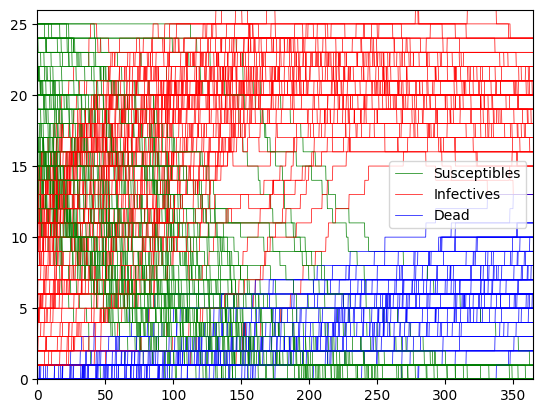

In [38]:
for tung in range(100):
  # need to reset characteristics of the graph, so that each plot makes sense
  for node in G.nodes:
    G.nodes[node]["S"] = [G.nodes[node]["S"][0]]
    G.nodes[node]["I"] = [G.nodes[node]["I"][0]]
    G.nodes[node]["D"] = [G.nodes[node]["D"][0]]


  node = 15
  time_range = 365 # days
  dt = .2 #day

  for step in range(int(time_range / dt)):
    intra_farm(node, dt, step)

  s = G.nodes[node]['S']
  i = G.nodes[node]['I']
  d = G.nodes[node]['D']


  t = [step * dt for step in range(len(s))]

  plt.plot(t, s, color='g', lw=0.5, label='Susceptibles'if tung==0 else '')
  plt.plot(t, i, color='r', lw=0.5, label='Infectives' if tung==0 else '')
  plt.plot(t, d, color='b', lw=0.5, label='Dead' if tung==0 else '')



plt.xlim(0, time_range)
plt.ylim(0, G.nodes[node]['N'])
plt.legend()

plt.show()

Now this can be done with all farms in the network (and even with multiple instances)

#### inter-farm dynamics
I would like to focus on (a) having a validated outcome from this code and (b) be able to make the model more realistic.

Also `b` requires more external input, `a` can be achieved through implementing inter-farm dynamics and then comparing a stochastic run through the whole network under these changing conditions:
- no policies applied
- culling after several days (variable)
- culling within 24 hours
- ring culling (all connected neighbours) within 24 and 48 hours

There are other policies that could be iterated on this, but this is a good start.

Then, across an extended time period, I can see how the effects of policies quantifiably affects the spread of disease (and how this could be balanced with the loss of animals).

Further models could include data incompleteness, where only after a given threshold would the policies be applied in each context (emulating variable testing rates/availability on farms, actual opportunity to test the livestock).

In [48]:
gamma = 1e-25 # I will adjust this value as well, but it's all arbitrary fine tuning

In [44]:
def inter_sum(node):
  sum = 0
  for neigh in G.predecessors(node):
    w = G[neigh][node]['weight']
    i = G.nodes[neigh]['I'][-1]
    n = G.nodes[neigh]['N']
    sum += w * i / n
  return sum

def inter_s(node, s, i, t):
  e = beta * s * i * t
  gam = gamma * inter_sum(node)
  return np.random.poisson(lam=((e+gam)))

def inter_farm(node, t, step):
  si = G.nodes[node]['S'][-1]
  ii = G.nodes[node]['I'][-1]
  di = G.nodes[node]['D'][-1]

  if step ==0:
    ii = np.random.randint(1, 15)
    si = si - ii # to properly initialise

  x = inter_s(node, si, ii, t)
  y = delta_d(ii, t)

  i2 = max(0,(ii + x - y))
  s2 = max(0,(si - x))
  d2 = di + y

  # update graph object
  G.nodes[node]['dS'] = s2
  G.nodes[node]['dI'] = i2
  G.nodes[node]['dD'] = d2

The plotting now will be across the entire network

I had some issues with this since I feel that this code will be very slow. Below is some pseudocode:

```
for each_step in range(timestep/dt):
  for node in G:
    # calculate delta_s, delta_i and delta_d

  for node in G:
    # apply delta_s, delta_i and delta_d

```

These have to be separated since each node is dependent on the changing values of its neighbours.

In [27]:
def delta_helper(node):
  s = G.nodes[node]['S'][-1] + G.nodes[node]['dS']
  G.nodes[node]['S'].append(s)

  i = G.nodes[node]['I'][-1] + G.nodes[node]['dI']
  G.nodes[node]['I'].append(i)

  d = G.nodes[node]['D'][-1] + G.nodes[node]['dD']
  G.nodes[node]['D'].append(d)

In [52]:
tot = np.array([G.nodes[node]['N'] for node in G.nodes])
total = tot.sum()

for tung in range(1):
  for node in G.nodes:
    # resets
    G.nodes[node]["S"] = [G.nodes[node]["S"][0]]
    G.nodes[node]["I"] = [G.nodes[node]["I"][0]]
    G.nodes[node]["D"] = [G.nodes[node]["D"][0]]
    G.nodes[node]["dS"] = 0
    G.nodes[node]["dI"] = 0
    G.nodes[node]["dD"] = 0

  time_range = 1 # days
  dt = .005 #day

  for step in range(int(time_range / dt)):
    for node in G.nodes:
      inter_farm(node, dt, step)
    for node in G.nodes:
      delta_helper(node)

  # collect the sum of attributes across the network
  s_matrix = np.array([G.nodes[node]['S'] for node in G.nodes])
  s = s_matrix.sum(axis=0).tolist()

  i_matrix = np.array([G.nodes[node]['I'] for node in G.nodes])
  i = i_matrix.sum(axis=0).tolist()

  d_matrix = np.array([G.nodes[node]['D'] for node in G.nodes])
  d = d_matrix.sum(axis=0).tolist()

  t = [step * dt for step in range(len(s))]

  plt.plot(t, s, color='g', lw=0.5, label='Susceptibles'if tung==0 else '')
  plt.plot(t, i, color='r', lw=0.5, label='Infectives' if tung==0 else '')
  plt.plot(t, d, color='b', lw=0.5, label='Dead' if tung==0 else '')

plt.xlim(0, time_range)
#plt.ylim(0, total)
plt.legend()

plt.show()

ValueError: lam value too large

In [51]:
node = 8
n = [G[neigh][node]['weight'] for neigh in G.predecessors(node)]
print(n)

[np.float64(0.9084756683235441), np.float64(0.08382230115402194), np.float64(0.49442902984438714), np.float64(0.15833685649112547), np.float64(0.579347936806305), np.float64(0.4629738570005756)]


### Additional Changes

#### Sliders
There are lots of proportionality constants, but I currently do not know how to fit those constants into a reasonable manner; looking into how this is done for models (and real data) will be pretty useful for progression.

Further:
- sliders to view the progression of the disease
- sliders for the changing of multiple parameters (a visual nod to finding an optimal combination of parameters)
- sliders adjusting probabilities and initial conditions

#### Heatmaps
I would like to run a big simulation of this a large number of times and then use a heatmap to overlay how different parameters (probabilities and connections) affected spreads.

This can then evolve to applying policy to farms (in a way that each farm does not have complete data, but works heuristically (although initial tests of the model would be complete)).

#### Policy Interventions
As the title suggests. Focusing on culling and adding culling to the differential equations.